In [1]:
%cd ..

C:\Users\malte\EvoMUSART23-repro-code


In [2]:
from evoaudio.pitch import Pitch
import numpy as np
from itertools import combinations
from typing import Callable, Set, List, Tuple, Dict
from enum import IntEnum
import pandas as pd

# Chord Distances 

From:

Rocher, Thomas & Robine, Matthias & Hanna, Pierre & Desainte-Catherine, Myriam. (2010). A Survey Of Chord Distances With Comparison For Chord Analysis. 
See: https://www.researchgate.net/publication/265984596_A_Survey_Of_Chord_Distances_With_Comparison_For_Chord_Analysis

In [3]:

def pcs(pitches: Set[Pitch]) -> Set[int]:
    return {p % 12 for p in pitches}

# 1. Affinity-based distance
def affinity_distance(c1: Set[Pitch], c2: Set[Pitch]) -> float:
    pc1, pc2 = pcs(c1), pcs(c2)
    intervals = [1,5,7,11]
    V = {i: sum(1 for p in pc1 if (p+i)%12 in intervals) for i in range(12)} 
    print(V)
    A = sum(V[i] for i in pc2)
    Amax = sum(V.values())
    return 1 - (Amax - A)/Amax if Amax > 0 else 1.0

# 2. Intervalic content distance
def intervalic_distance(c1: Set[Pitch], c2: Set[Pitch]) -> int:
    def iv(pcset):
        vec = [0]*6
        for x,y in combinations(pcset,2):
            d = min((y-x) % 12, (x-y)%12)
            if 1 <= d <= 6: vec[d-1]+=1
        return vec
    iv1, iv2 = iv(pcs(c1)), iv(pcs(c2))
    return sum(abs(a-b) for a,b in zip(iv1, iv2))

# 3. Estrada distance
def estrada_distance(c1: Set[Pitch], c2: Set[Pitch]) -> int:
    def texture_intervals(c):
        vals = sorted([p % 12 for p in c])
        base = vals[0]
        ints = {(p-base)%12 for p in vals[1:]} | {((vals[-1]-base)%12 + 12)%12}
        return ints
    v1, v2 = texture_intervals(c1), texture_intervals(c2)
    print(v1,v2)
    d = max(len(c1), len(c2)) - len(v1 & v2) - 1
    return max(d, 0)

# 4. Geometric (Spiral‑helix) distance
def geometric_distance(c1: Set[Pitch], c2: Set[Pitch], r=1.0, h=1.0) -> float:
    def pos(pc):
        k = pc
        return np.array([r*np.sin(k*np.pi/2), r*np.cos(k*np.pi/2), k*h])
    def centroid(c): return np.mean([pos(p%12) for p in c], axis=0)
    return np.linalg.norm(centroid(c1) - centroid(c2))

# 5. Tonal‑Pitch‑Space distance (symmetric version)
FIFTHS = {pc: idx for idx, pc in enumerate([0,7,2,9,4,11,6])}  # circle-of‑fifths mapping
def tps_distance(c1: Set[Pitch], c2: Set[Pitch], key: int=None) -> float:
    pc1, pc2 = pcs(c1), pcs(c2)
    root1, root2 = min(pc1) if key is None else root(c1), min(pc2)
    d_steps = abs(FIFTHS[root1%12] - FIFTHS[root2%12])
    j = min(d_steps, 7 - d_steps)
    def basic(pc_set):
        r = min(pc_set)
        triad = {r, (r+4)%12, (r+7)%12}
        diat = {(r+offs)%12 for offs in [0,2,4,5,7,9,11]}
        return triad | diat
    bs1, bs2 = basic(pc1), basic(pc2)
    k = len(bs1 ^ bs2) / 2
    return j + k

# 6. Paiement distance — (sum of minimal semitone differences mod 12)
def paiement_distance(c1: Set[Pitch], c2: Set[Pitch]) -> float:
    pc1, pc2 = list(pcs(c1)), list(pcs(c2))
    return sum(min((x-y)%12,(y-x)%12) for x in pc1 for y in pc2) / (len(pc1)*len(pc2))

# 7. Pitch interval (voice-leading) distance
def pitch_interval_distance(c1: Set[Pitch], c2: Set[Pitch]) -> float:
    a = sorted(p.value for p in c1)
    b = sorted(p.value for p in c2)
    return min(sum(abs(x-y) for x,y in zip(pa,pb)) for pa in combinations(a,2) for pb in [b])

In [4]:
def build_fifth_index_map():
    """
    Build a dict: pitch class (0-11) → index on the spiral of fifths (relative to C).
    """
    fifth_map = {}
    for i in range(12):
        pc = (7 * i) % 12
        #if i > 6:
        #    i = i-12
        if pc not in fifth_map:
            fifth_map[pc] = i
    return fifth_map

PITCH_CLASS_TO_FIFTH = build_fifth_index_map()

def pitch_class_to_fifth_index(pc):
    """
    Convert pitch class to its index along the fifths spiral.
    """
    pc_mod = pc % 12
    return PITCH_CLASS_TO_FIFTH[pc_mod]

def pitch_to_point(k, r=1.0, h=0.5):
    """Convert fifth index k to 3D point on the spiral."""
    angle = k * np.pi / 2
    x = r * np.sin(angle)
    y = r * np.cos(angle)
    z = k * h
    return np.array([x, y, z])

def chord_to_centroid(chord_pcs, r=1.0, h=0.5):
    """
    Convert a chord (given as pitch classes or MIDI notes) to its spiral centroid.
    """
    fifth_indices = [pitch_class_to_fifth_index(p % 12) for p in chord_pcs]
    points = [pitch_to_point(k, r=r, h=h) for k in fifth_indices]
    centroid = np.mean(points, axis=0)
    return centroid

def spiral_distance(chord1, chord2, r=1.0, h=0.5):
    """
    Compute geometric spiral distance between two chords (given as pitch classes or MIDI).
    """
    c1 = chord_to_centroid(chord1, r=r, h=h)
    c2 = chord_to_centroid(chord2, r=r, h=h)
    return np.linalg.norm(c1 - c2)

In [5]:
C_MAJOR = {Pitch.c4, Pitch.e4, Pitch.g4}                
D_MAJOR = {Pitch.d4, Pitch.fis4, Pitch.a4} 
C_MINOR = {Pitch.c4, Pitch.dis4, Pitch.g4}             
G_MAJOR = {Pitch.g2, Pitch.b3, Pitch.d3}                 
A_MINOR = {Pitch.a3, Pitch.c4, Pitch.e4}               
E_MAJOR = {Pitch.e4, Pitch.gis4, Pitch.b4}             
C7 = {Pitch.c4, Pitch.e4, Pitch.g4, Pitch.ais4}
G7 = {Pitch.g4, Pitch.b4, Pitch.d4, Pitch.f4}
A_MINOR_7 = {Pitch.a4, Pitch.c4, Pitch.e4, Pitch.g4}
F_MAJOR = {Pitch.f3, Pitch.a3, Pitch.c4}                   
C_MAJ_7 = {Pitch.c4, Pitch.e4, Pitch.g4, Pitch.b4}         
C_diat = {Pitch.c4, Pitch.cis4, Pitch.d4, Pitch.dis4,
         Pitch.e4, Pitch.f4, Pitch.fis4, Pitch.g4,
         Pitch.gis4, Pitch.a4, Pitch.ais4, Pitch.b4}        

In [6]:
print(geometric_distance(C_MAJOR,G_MAJOR,1,0.5))
print(spiral_distance(C_MAJOR,G7,1,0.5))

1.833333333333334
1.7955384522012705


From: Hurajová, K., Hutník, O. (2024). Towards Measuring the Distances of Chords of Different Cardinalities.

https://link.springer.com/chapter/10.1007/978-3-031-60638-0_27

I think the authors made a mistake in the examples or definition of the extension-distance.

In [7]:
def pcs(pitches: Set[Pitch]) -> Set[int]:
    return {p % 12 for p in pitches}

def full_pitch_vector(chord: Set[IntEnum]) -> np.ndarray:
    """Returns a 12D binary vector for pitch class content."""
    pc_vec = np.zeros((87,), dtype=int)
    for pitch in chord:
        pc_vec[pitch] = 1
    return pc_vec

def pitch_class_vector(chord: Set[IntEnum]) -> np.ndarray:
    """Returns a 12D binary vector for pitch class content."""
    pc_vec = np.zeros((12,), dtype=int)
    for pitch in chord:
        pc_vec[pitch % 12] = 1
    return pc_vec

def cyclic_pc_dist(u: int, v: int) -> int:
    return min((u - v) % 12, (v - u) % 12)

In [8]:
from itertools import permutations

def lp_norm(U: List[int], V: List[int], p: int = 1) -> float:
    """L^p norm (non-cyclic) between two equal-length pitch lists."""
    if len(U) != len(V):
        raise ValueError("lp_distance requires equal-length lists.")
    min_cost = float('inf')
    for perm in permutations(V):
        cost = sum(abs(u - v) ** p for u, v in zip(U, perm))
        min_cost = min(min_cost, cost)
    return min_cost ** (1 / p)

def lp_circular_norm(A: Set[int], B: Set[int], p: float = 2.0) -> float:
    """Computes the minimal ℓ_p norm between pitch-class sets A and B (mod 12) with circular distance."""
    if len(A) != len(B):
        raise ValueError("Sets must have the same cardinality")

    A_list = list(A)
    B_list = list(B)

    min_total = float('inf')
    for perm in permutations(B_list):
        total = sum(cyclic_pc_dist(a, b) ** p for a, b in zip(A_list, perm))
        norm = total ** (1 / p)
        if norm < min_total:
            min_total = norm

    return min_total

def lp_distance_12(chord1: Set[Pitch], chord2: Set[Pitch], p: float = 2) -> float:
    """Generalized p-norm (Minkowski) distance between pitch-class sets."""
    v1 = pitch_class_vector(chord1)
    v2 = pitch_class_vector(chord2)
    return np.linalg.norm((v1-v2), ord=p)

def lp_distance_all(chord1: Set[Pitch], chord2: Set[Pitch], p: float = 2) -> float:
    """Generalized p-norm (Minkowski) distance between pitch-class sets."""
    v1 = full_pitch_vector(chord1)
    v2 = full_pitch_vector(chord2)
    return np.linalg.norm((v1-v2), ord=p)

def hausdorff_distance(c1: Set[Pitch], c2: Set[Pitch]) -> float:
    X = sorted(pcs(c1))
    Y = sorted(pcs(c2))
    h_xy = max(min(cyclic_pc_dist(x,y) for y in Y) for x in X)
    h_yx = max(min(cyclic_pc_dist(y,x) for x in X) for y in Y)
    return max(h_xy, h_yx)

def GDp(c1: Set[Pitch], c2: Set[Pitch], p: float = 2) -> float:
    """Forward averaged Hausdorff component from U to V."""
    U_pc = sorted(pcs(c1))
    V_pc = sorted(pcs(c2))
    m = len(U_pc)
    if m == 0 or not V_pc:
        raise ValueError("Both sets must be non-empty")
    total = 0.0
    for u in U_pc:
        min_d_p = min(cyclic_pc_dist(u, v)**p for v in V_pc)
        total += min_d_p
    return (total / m) ** (1 / p)

def avg_hausdorff_p(U: Set[Pitch], V: Set[Pitch], p: float = 2) -> float:
    """Symmetric (two-sided) averaged Hausdorff distance Δ_p(U, V)."""
    return max(GDp(U, V, p), GDp(V, U, p))

def projection_distance_general(
    U: Set[Pitch],
    V: Set[Pitch],
    distance_func: Callable[[Set[int], Set[int]], float] = lp_circular_norm,
    p: float = 1
) -> float:

    m, n = len(U), len(V)
    if n < m:
        temp = U
        U = V
        V = temp

    U_pc = {u % 12 for u in U}
    V_list = list(V)

    max_dist = 0.0
    for combo in combinations(V_list, min(m,n)):
        S_pc = {v % 12 for v in combo}
        dist = distance_func(U_pc, S_pc, p)
        max_dist = max(max_dist, dist)

    return max_dist

def extension_distance(
    U: Set[Pitch],
    V: Set[Pitch],
    distance_func: Callable[[Set[int], Set[int]], float] = lp_circular_norm,
    extension_pool: Set[int] = set(range(12)),  # default: all pitch classes
    p: float = 1
) -> float:

    m, n = len(U), len(V)
    if m > n:
        temp = U
        U = V
        V = temp

    U_pc = {u % 12 for u in U}
    V_pc = {v % 12 for v in V}

    needed = abs(n - m)
    available_extensions = extension_pool - U_pc

    min_dist = float("inf")
    for extra in combinations(available_extensions, needed):
        S_pc = U_pc.union(extra)
        dist = distance_func(S_pc, V_pc, p)
        if dist < min_dist:
            min_dist = dist

    return min_dist

def fujita_distance(U: Set[int], V: Set[int]) -> float:
    """
    Fujita distance (2024): asymmetric double average over pitch-class differences
    using circular mod-12 distances and symmetric penalty for difference.
    """
    U = {u % 12 for u in U}
    V = {v % 12 for v in V}
    
    if not U or not V:
        raise ValueError("Pitch-class sets must be non-empty.")

    union_size = len(U | V)
    if union_size == 0:
        return 0.0

    sum1 = sum(cyclic_pc_dist(u, v) for u in U for v in (V - U))
    sum2 = sum(cyclic_pc_dist(u, v) for u in (U - V) for v in V)

    part1 = sum1 / (union_size * len(U)) if len(U) > 0 else 0
    part2 = sum2 / (union_size * len(V)) if len(V) > 0 else 0

    return part1 + part2

In [9]:
fujita_distance(C_MAJOR,G_MAJOR)
projection_distance_general(C_MAJOR,C_diat)

9.0

In [10]:
from scipy.stats import wasserstein_distance
def wasserstein_circular(U: Set[Pitch], V: Set[Pitch]) -> float:
    """Wasserstein distance between pitch-class sets using mod-12 circular distances."""
    
    m, n = len(U), len(V)
    if m < n:
        temp = U
        U = V
        V = temp
        
    min_cost = float("inf")
    X = list(pcs(U))
    Y = list(pcs(V))
    for perm in permutations(Y):
        cost = wasserstein_distance(X, perm)
        min_cost = min(min_cost, cost)
    return min_cost

def wasserstein(U: Set[IntEnum], V: Set[IntEnum]) -> float:
    """
    Wasserstein-1 distance (EMD) between two sets of Pitch enums (non-cyclic).
    Assumes uniform distribution over each chord.
    """
    X = [int(p) for p in U]
    Y = [int(p) for p in V]
    return wasserstein_distance(X, Y)

In [11]:
#wasserstein_circular(B_dim,D)

In [12]:
from scipy.optimize import linear_sum_assignment

def unbalanced_lp_distance_pitch(U: Set[Pitch], V: Set[Pitch], p: int = 1) -> float:
    """
    Computes a non-cyclic lp-distance between two sets of Pitch enums
    using optimal assignment and penalty for unmatched notes.
    """
    U_list = list(U)
    V_list = list(V)
    n, m = len(U_list), len(V_list)

    U_vals = np.array([int(p) for p in U_list])
    V_vals = np.array([int(p) for p in V_list])

    # Build cost matrix (n x m)
    cost_matrix = np.abs(U_vals[:, None] - V_vals[None, :]) ** p

    # Perform linear sum assignment on full matrix
    if n <= m:
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        matched_cost = cost_matrix[row_ind, col_ind].sum()
        unmatched = m - n
    else:
        row_ind, col_ind = linear_sum_assignment(cost_matrix.T)
        matched_cost = cost_matrix[col_ind, row_ind].sum()
        unmatched = n - m

    # Penalty for unmatched notes: use max distance in MIDI range
    max_pitch_diff = 108 - 21
    unmatched_cost = unmatched/8 * (max_pitch_diff ** p)

    total_cost = matched_cost + unmatched_cost
    return (total_cost / max(n, m)) ** (1 / p)

In [13]:
unbalanced_lp_distance_pitch(C_MAJOR,F_MAJOR)

7.0

In [14]:
DistanceFunction = Callable[[Set[IntEnum], Set[IntEnum]], float]

def evaluate_chord_distances(
    chord_pairs: List[Tuple[Set[IntEnum], Set[IntEnum]]],
    distance_functions: Dict[str, DistanceFunction]
) -> pd.DataFrame:
    records = []

    for idx, (U, V) in enumerate(chord_pairs):
        row = {"pair": f"Pair {idx + 1}"}
        for name, func in distance_functions.items():
            try:
                row[name] = func(U, V)
            except Exception as e:
                row[name] = f"ERROR: {e}"
        records.append(row)

    return pd.DataFrame(records)

def compare_to_chord(reference: Set[IntEnum], chords: Dict[str, Set[IntEnum]], distances: Dict[str, Callable]):
    results = []

    for name, chord in chords.items():
        row = {"Chord": name}
        for dname, dist_func in distances.items():
            try:
                row[dname] = dist_func(reference, chord)
            except Exception as e:
                row[dname] = f"ERR: {str(e)}"
        results.append(row)
    
    return pd.DataFrame(results)

In [15]:
C_maj = {Pitch.c4, Pitch.e4, Pitch.g4}
C_maj_inverted = {Pitch.c5, Pitch.e4, Pitch.g4}
C_maj_octave_up = {Pitch.c5, Pitch.e5, Pitch.g5}
C_min = {Pitch.c4, Pitch.dis4, Pitch.g4}
C7 = {Pitch.c4, Pitch.e4, Pitch.g4, Pitch.b4}
D_maj = {Pitch.d4, Pitch.fis4, Pitch.a4}
E_maj = {Pitch.e4, Pitch.gis4, Pitch.b4}
F_maj = {Pitch.f4, Pitch.a4, Pitch.c5}
G_maj = {Pitch.g4, Pitch.b4, Pitch.d5}
G7 = {Pitch.g4, Pitch.b4, Pitch.d5, Pitch.f5}
A_min = {Pitch.a4, Pitch.c5, Pitch.e5}
B_dim = {Pitch.b4, Pitch.d5, Pitch.f5}
C = {Pitch.c4}
D = {Pitch.d4}
C_all = {Pitch.c4, Pitch.cis4, Pitch.d4, Pitch.dis4,
         Pitch.e4, Pitch.f4, Pitch.fis4, Pitch.g4,
         Pitch.gis4, Pitch.a4, Pitch.ais4, Pitch.b4}

In [16]:
distance_functions = {
    "Intervalic": intervalic_distance,
    "l2 12": lp_distance_12,
    "Hausdorff": hausdorff_distance,
    "Avg Hausdorff, p=2": avg_hausdorff_p,
    "Projection with l1-norm": projection_distance_general,
    "Fujita": fujita_distance,
    "Circular 1-Wasserstein": wasserstein_circular,
    "1-Wasserstein": wasserstein,
    "l2 all": lp_distance_all,
    "Geometric, r=1, h=0.5": spiral_distance

}
chords = {
    "C_maj": C_maj,
    "C_maj_inverted": C_maj_inverted,
    "C_maj_octave_up": C_maj_octave_up,
    "C_min": C_min,
    "C7": C7,
    "D_maj": D_maj,
    "E_maj": E_maj,
    "F_maj": F_maj,
    "G_maj": G_maj,
    "G7": G7,
    "A_min": A_min,
    "B_dim": B_dim,
    "C": C,
    "D": D,
    "C_all": C_all
}

In [17]:
df = compare_to_chord(C_maj, chords, distance_functions)
print(df)

              Chord  Intervalic     l2 12  Hausdorff  Avg Hausdorff, p=2  \
0             C_maj           0  0.000000          0            0.000000   
1    C_maj_inverted           0  0.000000          0            0.000000   
2   C_maj_octave_up           0  0.000000          0            0.000000   
3             C_min           0  1.414214          1            0.577350   
4                C7           3  1.000000          1            0.500000   
5             D_maj           0  2.449490          2            1.732051   
6             E_maj           0  2.000000          1            0.816497   
7             F_maj           0  2.000000          2            1.290994   
8             G_maj           0  2.000000          2            1.290994   
9                G7           3  2.236068          2            1.224745   
10            A_min           0  1.414214          2            1.154701   
11            B_dim           4  2.449490          2            1.414214   
12          

In [18]:
import librosa
from glob import glob
import matplotlib.pyplot as plt
import numpy as np

from evoaudio.base_algorithms import approximate_piece
from evoaudio.base_sample import BaseSample
from evoaudio.individual import BaseIndividual
from evoaudio.mutations import Mutator
from evoaudio.population import Population
from evoaudio.sample_library import SampleLibrary
from evoaudio.population_logging import PopulationLogger
from evoaudio.jaccard_new import calc_jaccard_for_chord_approximation
from evoaudio.fitness import fitness
from parsing.arff_parsing import parse_arff

In [19]:
sample_lib = SampleLibrary()

Loading samples:   0%|          | 0/6826 [00:00<?, ?it/s]

In [20]:
class GroundTruthIndividual(BaseIndividual):
    def __init__(self, phi: float = 0.1, hold_delay: int = 5512):
        super().__init__(phi)
        #self.hold_delay = np.random.randint(low=0, high=44100) # Random delay between 0 and 2 seconds
        self.hold_delay = 5512
        self.holds = []

    def __str__(self):
        s = f"Fitness: {self.fitness} | " + ", ".join(str(x) for x in self.samples) + ", ".join(str(hold) for hold in self.holds)
        return s

    def add_sample(self, sample:BaseSample, hold:bool):
        self.samples.append(sample)
        self.holds.append(hold)

    def remove_sample(self, remove_idx):
        self.samples.pop(remove_idx)
        self.holds.pop(remove_idx)

    def to_mixdown(self) -> np.ndarray:
        """Creates a mix of the samples contained in the collection.

        Returns
        -------
        np.ndarray
            Mix of the samples.
        """
        ys_holding = []
        for i in range(len(self.samples)):
            if self.holds[i]:
                ys_holding.append(self.samples[i].y[self.hold_delay:])
            else:
                ys_holding.append(self.samples[i].y)
        # Resize by expanding all samples to the same length
        max_length = np.max([len(y) for y in ys_holding])
        ys_equal_length = [np.pad(y, (0, max_length - len(y))) for y in ys_holding]
        return np.sum(ys_equal_length, axis=0)
    
    def calc_abs_stft(self):
        """Calculates the absolute stft values of the sample mix.
        """
        stft = librosa.stft(self.to_mixdown()[:22050])
        return np.abs(stft)
    
    @classmethod
    def create_random_individual(cls, sample_lib:SampleLibrary, max_samples:int=5, sample_num_p:list[float]=[0.1, 0.3, 0.3, 0.2, 0.1], phi:float=0.1):
        individual = cls(phi=phi)
        for _ in range(np.random.choice(list(range(max_samples)), p=sample_num_p) + 1):
            individual.add_sample(sample_lib.get_random_sample_uniform(), hold=np.random.choice(a=[False, True], p=[0.8, 0.2]))
        return individual
    
    @classmethod
    def create_individual(cls, sample_lib:SampleLibrary, n_samples:int, instruments:List[str],
                          styles:List[str], pitches:List[Pitch], phi:float=0.1):
        individual = cls(phi=phi)
        for i in range(n_samples):
            individual.add_sample(sample_lib.get_sample(instrument = instruments[i], style = styles[i], pitch = pitches[i]), hold=False)
        return individual

In [21]:
instruments = ["Piano", "Piano", "Piano"]
styles = ["The_Grandeur", "The_Grandeur", "The_Grandeur"]
pitches_C = [Pitch.c4, Pitch.e4, Pitch.g4]
pitches_G = [Pitch.g4, Pitch.b4, Pitch.d4]

In [22]:
individual_C = GroundTruthIndividual.create_individual(sample_lib=sample_lib,
                                                       n_samples=3, instruments=instruments,
                                                       styles=styles, pitches=pitches_C)
individual_G = GroundTruthIndividual.create_individual(sample_lib=sample_lib, n_samples=3,
                                                       instruments=instruments, styles=styles,
                                                       pitches=pitches_G)

In [23]:
x = individual_C.calc_abs_stft()
y = individual_G.calc_abs_stft()
print(fitness(x,y))

2.7577786775914634


C:\Users\malte\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\spectrum.py:256: UserWarning: n_fft=2048 is too large for input signal of length=44
  warnings.warn(


In [24]:
instruments = ["Piano"] * 3
styles = ["The_Grandeur"] * 3
pitches_C = [Pitch.c4, Pitch.e4, Pitch.g4]

individual_C = GroundTruthIndividual.create_individual(
    sample_lib=sample_lib,
    n_samples=3,
    instruments=instruments,
    styles=styles,
    pitches=pitches_C
)

x = individual_C.calc_abs_stft()

audio_distances = []
# 3. Loop through all chords and compute the audio-based fitness
for chord_name, chord_pitches in chords.items():
    try:
        if len(chord_pitches) == 0:
            raise ValueError("Empty chord")
        pitches_list = list(chord_pitches)

        # Create individual for the target chord
        individual = GroundTruthIndividual.create_individual(
            sample_lib=sample_lib,
            n_samples=len(pitches_list),
            instruments=["Piano"] * len(pitches_list),
            styles=["The_Grandeur"] * len(pitches_list),
            pitches=pitches_list
        )

        y = individual.calc_abs_stft()
        dist = round(fitness(x, y), 4)
    except Exception as e:
        dist = f"ERROR: {e}"

    audio_distances.append(dist)
    
df["Fitness"] = audio_distances
print(df)

              Chord  Intervalic     l2 12  Hausdorff  Avg Hausdorff, p=2  \
0             C_maj           0  0.000000          0            0.000000   
1    C_maj_inverted           0  0.000000          0            0.000000   
2   C_maj_octave_up           0  0.000000          0            0.000000   
3             C_min           0  1.414214          1            0.577350   
4                C7           3  1.000000          1            0.500000   
5             D_maj           0  2.449490          2            1.732051   
6             E_maj           0  2.000000          1            0.816497   
7             F_maj           0  2.000000          2            1.290994   
8             G_maj           0  2.000000          2            1.290994   
9                G7           3  2.236068          2            1.224745   
10            A_min           0  1.414214          2            1.154701   
11            B_dim           4  2.449490          2            1.414214   
12          

In [25]:
def Ginsel_dist(x,y):
    interval = abs(x - y)

    if interval == 0:
        return 0
    elif interval == 12:
        return 1
    elif interval == 7:
        return 2
    elif interval in {3, 4, 5, 9}:
        return 3
    elif interval in {1, 2, 6, 8, 10, 11}:
        return 4
    else:
        return 5

def hausdorff_distance_G(c1: Set[Pitch], c2: Set[Pitch]) -> float:
    X = [int(p) for p in c1]
    Y = [int(p) for p in c2]
    h_xy = max(min(Ginsel_dist(x,y) for y in Y) for x in X)
    h_yx = max(min(Ginsel_dist(y,x) for x in X) for y in Y)
    return max(h_xy, h_yx)

def GDp_G(c1: Set[Pitch], c2: Set[Pitch], p: float = 2) -> float:
    """Forward averaged Hausdorff component from U to V."""
    U_pc = [int(p) for p in c1]
    V_pc = [int(p) for p in c2]
    m = len(U_pc)
    if m == 0 or not V_pc:
        raise ValueError("Both sets must be non-empty")
    total = 0.0
    for u in U_pc:
        min_d_p = min(Ginsel_dist(u, v)**p for v in V_pc)
        total += min_d_p
    return (total / m) ** (1 / p)

def avg_hausdorff_p_G(U: Set[Pitch], V: Set[Pitch], p: float = 2) -> float:
    """Symmetric (two-sided) averaged Hausdorff distance Δ_p(U, V)."""
    return max(GDp_G(U, V, p), GDp_G(V, U, p))

def fujita_distance_G(U: Set[int], V: Set[int]) -> float:
    """
    Fujita distance (2024): asymmetric double average over pitch-class differences
    using circular mod-12 distances and symmetric penalty for difference.
    """
    U = {u for u in U}
    V = {v for v in V}
    
    if not U or not V:
        raise ValueError("Pitch-class sets must be non-empty.")

    union_size = len(U | V)
    if union_size == 0:
        return 0.0

    sum1 = sum(Ginsel_dist(u, v) for u in U for v in (V - U))
    sum2 = sum(Ginsel_dist(u, v) for u in (U - V) for v in V)

    part1 = sum1 / (union_size * len(U)) if len(U) > 0 else 0
    part2 = sum2 / (union_size * len(V)) if len(V) > 0 else 0

    return part1 + part2

In [26]:
distance_functions = {
    "Hausdorff": hausdorff_distance,
    "Avg Hausdorff, p=2": avg_hausdorff_p,
    "Fujita": fujita_distance,
    "Hausdorff Ginsel": hausdorff_distance_G,
    "Avg Hausdorff Ginsel, p=2": avg_hausdorff_p_G,
    "Fujita Ginsel": fujita_distance_G
}
chords = {
    "C_maj": C_maj,
    "C_maj_inverted": C_maj_inverted,
    "C_maj_octave_up": C_maj_octave_up,
    "C_min": C_min,
    "C7": C7,
    "D_maj": D_maj,
    "E_maj": E_maj,
    "F_maj": F_maj,
    "G_maj": G_maj,
    "G7": G7,
    "A_min": A_min,
    "B_dim": B_dim,
    "C": C,
    "D": D,
    "C_all": C_all
}

In [27]:
df_Ginsel = compare_to_chord(C_maj, chords, distance_functions)
print(df_Ginsel)

              Chord  Hausdorff  Avg Hausdorff, p=2    Fujita  \
0             C_maj          0            0.000000  0.000000   
1    C_maj_inverted          0            0.000000  0.000000   
2   C_maj_octave_up          0            0.000000  0.000000   
3             C_min          1            0.577350  1.333333   
4                C7          1            0.500000  0.833333   
5             D_maj          2            1.732051  3.111111   
6             E_maj          1            0.816497  2.400000   
7             F_maj          2            1.290994  2.466667   
8             G_maj          2            1.290994  2.466667   
9                G7          2            1.224745  2.500000   
10            A_min          2            1.154701  1.666667   
11            B_dim          2            1.414214  3.000000   
12                C          5            3.696846  3.000000   
13                D          5            3.316625  3.000000   
14            C_all          2          

In [28]:
df_Ginsel["Fitness"] = audio_distances
print(df_Ginsel)

              Chord  Hausdorff  Avg Hausdorff, p=2    Fujita  \
0             C_maj          0            0.000000  0.000000   
1    C_maj_inverted          0            0.000000  0.000000   
2   C_maj_octave_up          0            0.000000  0.000000   
3             C_min          1            0.577350  1.333333   
4                C7          1            0.500000  0.833333   
5             D_maj          2            1.732051  3.111111   
6             E_maj          1            0.816497  2.400000   
7             F_maj          2            1.290994  2.466667   
8             G_maj          2            1.290994  2.466667   
9                G7          2            1.224745  2.500000   
10            A_min          2            1.154701  1.666667   
11            B_dim          2            1.414214  3.000000   
12                C          5            3.696846  3.000000   
13                D          5            3.316625  3.000000   
14            C_all          2          

In [29]:
def major_chord(root: Pitch) -> set[Pitch]:
    return {root, Pitch(root + 4), Pitch(root + 7)}

def minor_chord(root: Pitch) -> set[Pitch]:
    return {root, Pitch(root + 3), Pitch(root + 7)}

def dominant7_chord(root: Pitch) -> set[Pitch]:
    return {root, Pitch(root + 4), Pitch(root + 7), Pitch(root + 10)}

# --- root labels for 12 semitones ---

root_labels = ["C", "C#", "D", "D#", "E", "F",
               "F#", "G", "G#", "A", "A#", "B"]

# map labels to Pitch enum (all starting in octave 4)
roots = {
    name: Pitch(Pitch.c4 + i)  # Pitch.c4 = 60, then shift up by i semitones
    for i, name in enumerate(root_labels)
}

# --- build chord dictionary ---

chords = {}

# all 12 major chords
for name, root in roots.items():
    chords[f"{name}_maj"] = major_chord(root)

# all 12 minor chords
for name, root in roots.items():
    chords[f"{name}_min"] = minor_chord(root)

# all 12 dominant 7ths
for name, root in roots.items():
    chords[f"{name}7"] = dominant7_chord(root)

print(list(chords.keys())[:10])  # preview first 10 chord names

['C_maj', 'C#_maj', 'D_maj', 'D#_maj', 'E_maj', 'F_maj', 'F#_maj', 'G_maj', 'G#_maj', 'A_maj']


               x         y
C_maj  -1.004492  1.572008
C#_maj  1.899197  0.671443
D_maj  -0.671189 -1.848662
D#_maj -1.847883  0.568261
E_maj   0.796022  1.742599
F_maj   0.872916  0.215447
F#_maj  1.093578 -1.600133
G_maj  -1.923124 -0.730530
G#_maj -0.138022  1.887466
A_maj   1.882973 -0.440249
A#_maj  0.160118 -1.725448
B_maj  -1.120094 -0.312202


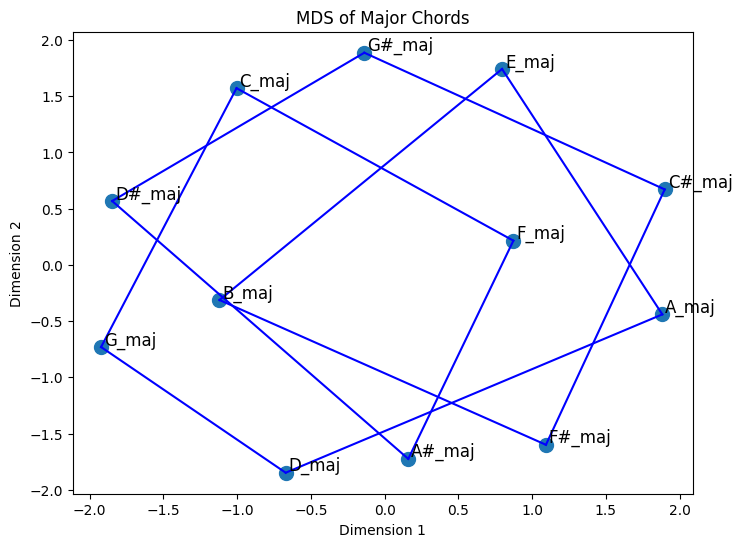

In [51]:
from sklearn.manifold import MDS
distance_functions = {
    "Intervalic": intervalic_distance,
    "l2 12": lp_distance_12,
    "Hausdorff": hausdorff_distance,
    "Avg Hausdorff, p=2": avg_hausdorff_p,
    "Projection with l1-norm": projection_distance_general,
    "Fujita": fujita_distance,
    "Circular 1-Wasserstein": wasserstein_circular,
    "1-Wasserstein": wasserstein,
    "l2 all": lp_distance_all,
    "Geometric, r=1, h=0.5": spiral_distance,
    "Hausdorff Ginsel": hausdorff_distance_G,
    "Avg Hausdorff Ginsel, p=2": avg_hausdorff_p_G,
    "Fujita Ginsel": fujita_distance_G
}


distance_func = fujita_distance
major_chords = {
    name: chord for name, chord in chords.items() if "maj" in name
}

names = list(major_chords.keys())
n = len(names)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i < j:
            d = distance_func(major_chords[names[i]], major_chords[names[j]])
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
df_dist = pd.DataFrame(dist_matrix, index=names, columns=names)

# Run MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist_matrix)

# Create DataFrame with 2D coordinates
df_coords = pd.DataFrame(coords, index=names, columns=["x", "y"])
print(df_coords)

# Example plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_coords["x"], df_coords["y"], s=100)

for name, (x, y) in df_coords.iterrows():
    plt.text(x+0.02, y+0.02, name, fontsize=12)
    
    
circle_of_fifths = [
    "C_maj", "G_maj", "D_maj", "A_maj", "E_maj", "B_maj",
    "F#_maj", "C#_maj", "G#_maj", "D#_maj", "A#_maj", "F_maj"
]

for i in range(len(circle_of_fifths)):
    c1 = circle_of_fifths[i]
    c2 = circle_of_fifths[(i + 1) % len(circle_of_fifths)]  # wrap around
    
    if c1 in df_coords.index and c2 in df_coords.index:
        x_values = [df_coords.loc[c1, "x"], df_coords.loc[c2, "x"]]
        y_values = [df_coords.loc[c1, "y"], df_coords.loc[c2, "y"]]
        
        plt.plot(x_values, y_values, linestyle="-", color = "blue")
    
    
plt.title("MDS of Major Chords")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

               x         y         z
C_maj  -0.368379  1.846730 -0.162898
C#_maj  1.019900 -0.801502 -1.318283
D_maj  -1.186137 -1.380099 -0.342138
D#_maj  0.257790  0.280345  1.842183
E_maj   0.982941  1.143263 -1.083527
F_maj  -1.564943  0.358607 -0.902164
F#_maj  0.498396 -1.810198  0.185974
G_maj  -1.034473  0.907867  1.222122
G#_maj  1.469375  1.103394  0.257086
A_maj  -0.376186 -0.115516 -1.839011
A#_maj -1.113487 -1.047788  1.066904
B_maj   1.415203 -0.485104  1.073753


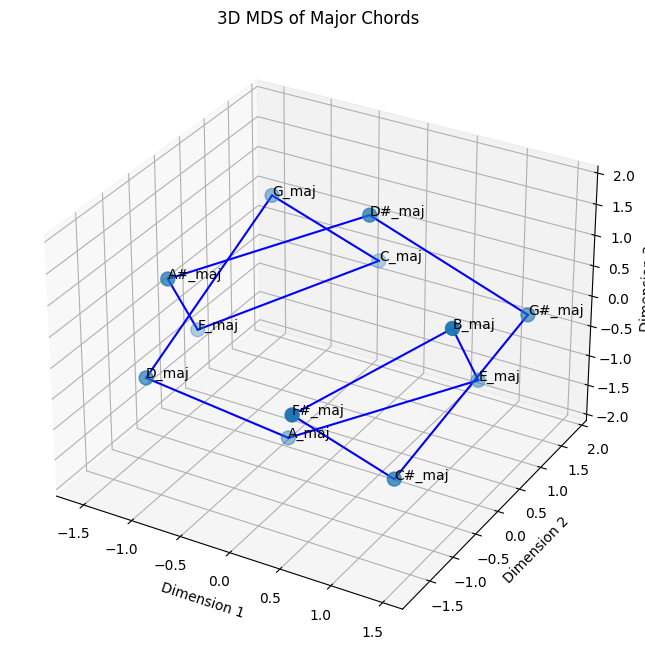

In [52]:
from sklearn.manifold import MDS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -------------------------------------------------
# Choose distance function
# -------------------------------------------------
distance_func = fujita_distance  # swap freely

# -------------------------------------------------
# Filter major chords
# -------------------------------------------------
major_chords = {
    name: chord for name, chord in chords.items() if "maj" in name
}

names = list(major_chords.keys())
n = len(names)

# -------------------------------------------------
# Build distance matrix
# -------------------------------------------------
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i < j:
            d = distance_func(major_chords[names[i]], major_chords[names[j]])
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d

df_dist = pd.DataFrame(dist_matrix, index=names, columns=names)

# -------------------------------------------------
# 3D MDS
# -------------------------------------------------
mds = MDS(n_components=3, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist_matrix)

df_coords = pd.DataFrame(coords, index=names, columns=["x", "y", "z"])

print(df_coords)

# -------------------------------------------------
# 3D Plot
# -------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_coords["x"], df_coords["y"], df_coords["z"], s=100)

for name, row in df_coords.iterrows():
    ax.text(row["x"], row["y"], row["z"], name, fontsize=10)

# -------------------------------------------------
# Circle of fifths
# -------------------------------------------------
circle_of_fifths = [
    "C_maj", "G_maj", "D_maj", "A_maj", "E_maj", "B_maj",
    "F#_maj", "C#_maj", "G#_maj", "D#_maj", "A#_maj", "F_maj"
]

for i in range(len(circle_of_fifths)):
    c1 = circle_of_fifths[i]
    c2 = circle_of_fifths[(i + 1) % len(circle_of_fifths)]

    if c1 in df_coords.index and c2 in df_coords.index:
        x = [df_coords.loc[c1, "x"], df_coords.loc[c2, "x"]]
        y = [df_coords.loc[c1, "y"], df_coords.loc[c2, "y"]]
        z = [df_coords.loc[c1, "z"], df_coords.loc[c2, "z"]]

        ax.plot(x, y, z, color="blue", linestyle="-")

# -------------------------------------------------
# Labels
# -------------------------------------------------
ax.set_title("3D MDS of Major Chords")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")

plt.show()